In [1]:
# Import libraries
import pandas as pd

# Import graphing libraries
import matplotlib.pyplot as plt
import seaborn as sns  # Theme
import pickle
from matplotlib.dates import  MonthLocator, DateFormatter
from pathlib import Path
import sys
import os
sys.path.append(str(Path(os.getcwd()).parent))
from utils.wrappers import measure_time_and_space, measure_time
from utils.data_structures import RollingMeanArray

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
# --- Import dataset ---
dataset = pd.read_csv("../data/mag7_stocks.csv", parse_dates=["Date"])
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348 entries, 0 to 1347
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          1348 non-null   datetime64[ns]
 1   Ticker        1348 non-null   object        
 2   Open          1348 non-null   int64         
 3   High          1348 non-null   int64         
 4   Low           1348 non-null   int64         
 5   Close         1348 non-null   int64         
 6   Volume        1348 non-null   int64         
 7   MA_30         1145 non-null   float64       
 8   MA_90         725 non-null    float64       
 9   MA_180        95 non-null     float64       
 10  Run_Group     1341 non-null   float64       
 11  Daily_Return  1347 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(5), object(1)
memory usage: 126.5+ KB


In [4]:
# Show companies
companies = dataset["Ticker"].dropna().unique().tolist()
print(companies)

['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']


In [5]:
# Identify column names from dataset
COL_DATE = "Date"
COL_NAME = "Ticker"
COL_OPEN = "Open"
COL_HIGH = "High"
COL_LOW = "Low"
COL_CLOSE = "Close"
COL_VOLUME = "Volume"
COL_MA30 = "MA_30"
COL_MA90 = "MA_90"
COL_MA180 = "MA_180"
COL_RUN_GROUP = "Run_Group"

In [6]:
# Theme of graphs
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.frameon": True,
    "legend.framealpha": 1,
})

In [7]:
pd.date_range(start=dataset[COL_DATE].iloc[-1] + pd.Timedelta(days=1), periods=5)

DatetimeIndex(['2025-10-09', '2025-10-10', '2025-10-11', '2025-10-12',
               '2025-10-13'],
              dtype='datetime64[ns]', freq='D')

In [8]:
RollingMeanArray.predict(dataset[COL_CLOSE].tolist(), window=30, steps=5)

[399.6,
 401.25333333333333,
 403.0951111111111,
 405.39828148148155,
 407.9448908641976]

In [9]:
@measure_time_and_space
def plot_stock_data_naive(df,  xlabel="Date", ylabel="Price (USD)",  min_run_length=3, num_predictions=30):
    """
    Plot stock data with moving averages.
    """
    # Plot and label stock prices*excluding moving averages
    fig, ax = plt.subplots()
    ax.plot(df[COL_DATE], df[COL_HIGH], label="High", color='tab:blue')
    ax.plot(df[COL_DATE], df[COL_LOW], label="Low", color='tab:orange')
    ax.plot(df[COL_DATE], df[COL_OPEN], label="Open", color='tab:green')
    ax.plot(df[COL_DATE], df[COL_CLOSE], label="Close", color='tab:red', linewidth=1.2)

    # Plot moving averages if they exist in the DataFrame
    if COL_MA30 in df.columns:
        ax.plot(df[COL_DATE], df[COL_MA30], label="MA 30", color='tab:purple', linestyle='--')
    if COL_MA90 in df.columns:
        ax.plot(df[COL_DATE], df[COL_MA90], label="MA 90", color='tab:brown', linestyle='--')
    if COL_MA180 in df.columns:
        ax.plot(df[COL_DATE], df[COL_MA180], label="MA 180", color='tab:pink', linestyle='--')
    
    #Predicting next 30 days using rolling mean

    #Prediction using window size of 30
    predicted_close_30 = RollingMeanArray.predict(df[COL_CLOSE].tolist(), window=30, steps=num_predictions)
    date_range = pd.date_range(start=df[COL_DATE].iloc[-1] + pd.Timedelta(days=1), periods=num_predictions)
    ax.plot(date_range, predicted_close_30, label="Predicted 30", color='tab:purple', linestyle=':', linewidth=2)

    #Prediction using window size of 90
    predicted_close_90 = RollingMeanArray.predict(df[COL_CLOSE].tolist(), window=90, steps=num_predictions)
    date_range = pd.date_range(start=df[COL_DATE].iloc[-1] + pd.Timedelta(days=1), periods=num_predictions)
    ax.plot(date_range, predicted_close_90, label="Predicted 90", color='tab:brown', linestyle=':', linewidth=2)

    #Prediction using window size of 180
    predicted_close_180 = RollingMeanArray.predict(df[COL_CLOSE].tolist(), window=180, steps=num_predictions)
    date_range = pd.date_range(start=df[COL_DATE].iloc[-1] + pd.Timedelta(days=1), periods=num_predictions)
    ax.plot(date_range, predicted_close_180, label="Predicted 180", color='tab:pink', linestyle=':', linewidth=2)


    

    # Support/resistance window (fixed to show long-term range)
    sr_window = 60

     # Calculate support and resistance
    support = df[COL_LOW].rolling(window=sr_window, min_periods=1).min()
    resistance = df[COL_HIGH].rolling(window=sr_window, min_periods=1).max()

    # Use only one key recent support/resistance level (latest)
    support_levels = [support.tail(100).min()]
    resistance_levels = [resistance.tail(100).max()]
    
    # Plot support and resistance lines (thin continuous lines)
    for level in support_levels:
        ax.axhline(y=level, color='blue', linestyle='-', linewidth=0.8, alpha=0.6,
                   label="Support" if "Support" not in ax.get_legend_handles_labels()[1] else "")
    for level in resistance_levels:
        ax.axhline(y=level, color='orange', linestyle='-', linewidth=0.8, alpha=0.6,
                   label="Resistance" if "Resistance" not in ax.get_legend_handles_labels()[1] else "")
        
    
    df["Consecutive_Runs"] = (df["Run_Group"] != df["Run_Group"].shift()).cumsum()
    
    # Keep only runs meeting the minimum streak length
    run_segments = df.groupby("Consecutive_Runs").filter(lambda x: len(x) >= min_run_length)


    # Highlight upward/downward runs (drawn behind other lines)
    for _, group in run_segments.groupby("Consecutive_Runs"):
        color = 'green' if group["Run_Group"].iloc[0] == 1.0 else 'red' if group["Run_Group"].iloc[0] == -1.0 else 'gray' if group["Run_Group"].iloc[0] == 0 else 'yellow'
        ax.axvspan(group[COL_DATE].iloc[0], group[COL_DATE].iloc[-1],
                   color=color, alpha=0.25, zorder=0)
        
    
   
        
    # Grid and x-axis formatting
    ax.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.7)
    ax.grid(True, which='minor', linestyle='--', linewidth=0.3, alpha=0.4)

    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))

    
    plt.title(df[COL_NAME].iloc[0] + " HLOC Values, MAs & Runs")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()

    ax.legend(ncol=3)
    plt.tight_layout()
   
    
    plt.grid(True)

    
    plt.show()



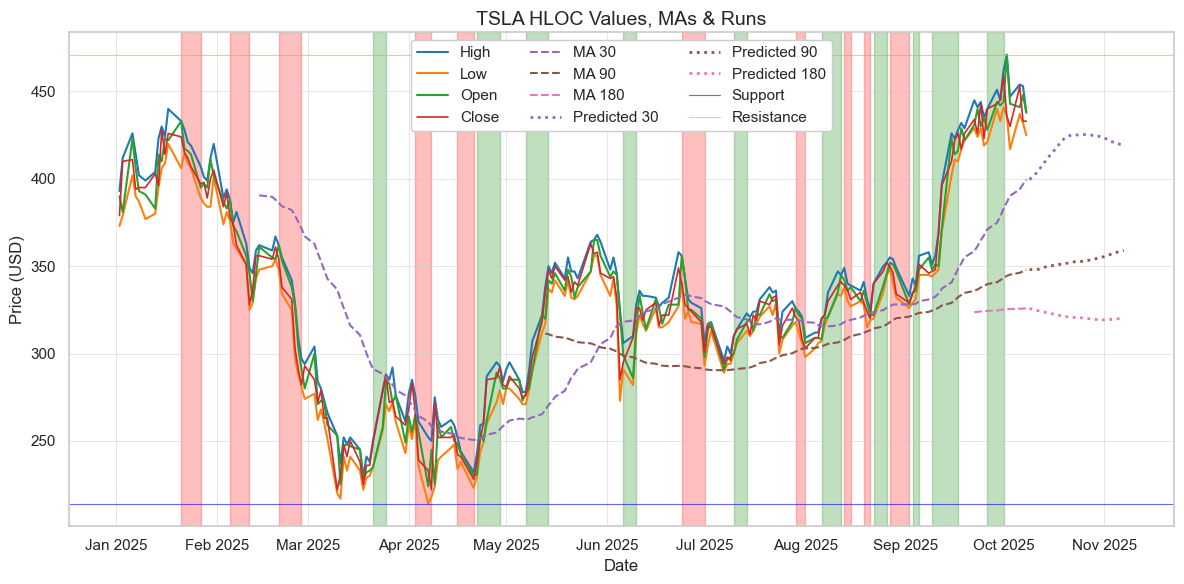

[plot_stock_data_naive] Time elapsed: 0.958751 seconds
[plot_stock_data_naive] Peak memory: 2683.02 KB


In [10]:
plot_stock_data_naive(dataset[dataset[COL_NAME] == "TSLA"])

In [11]:
plot_stock_data(dataset[dataset[COL_NAME] == "TSLA"])

NameError: name 'plot_stock_data' is not defined

In [ ]:
@measure_time_and_space
def plot_base_prices(ax, df):
    """Plot the base HLOC price data."""
    ax.plot(df[COL_DATE], df[COL_HIGH], label="High", color='tab:blue')
    ax.plot(df[COL_DATE], df[COL_LOW], label="Low", color='tab:orange')
    ax.plot(df[COL_DATE], df[COL_OPEN], label="Open", color='tab:green')
    ax.plot(df[COL_DATE], df[COL_CLOSE], label="Close", color='tab:red', linewidth=1.2)


@measure_time_and_space
def plot_moving_averages(ax, df):
    """Plot moving averages if they exist."""
    ma_colors = {
        COL_MA30: 'tab:purple',
        COL_MA90: 'tab:brown',
        COL_MA180: 'tab:pink'
    }
    for col, color in ma_colors.items():
        if col in df.columns:
            ax.plot(df[COL_DATE], df[col], label=col.replace("COL_", ""), color=color, linestyle='--')

@measure_time_and_space
def plot_predictions(ax, df, num_predictions=30):
    """Plot predictions using different window sizes."""
    close_values = df[COL_CLOSE].tolist()
    last_date = df[COL_DATE].iloc[-1]
    colors = {30: 'tab:purple', 90: 'tab:brown', 180: 'tab:pink'}

    for window, color in colors.items():
        predicted = RollingMeanArray.predict(close_values, window, num_predictions)
        date_range = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=num_predictions)
        ax.plot(date_range, predicted, label=f"Predicted {window}", color=color, linestyle=':', linewidth=2)

@measure_time_and_space
def plot_support_resistance(ax, df, sr_window=60):
    """Compute and plot support/resistance levels."""
    support = df[COL_LOW].rolling(window=sr_window, min_periods=1).min()
    resistance = df[COL_HIGH].rolling(window=sr_window, min_periods=1).max()

    support_levels = [support.tail(100).min()]
    resistance_levels = [resistance.tail(100).max()]

    for level in support_levels:
        ax.axhline(y=level, color='blue', linestyle='-', linewidth=0.8, alpha=0.6,
                   label="Support" if "Support" not in ax.get_legend_handles_labels()[1] else "")
    for level in resistance_levels:
        ax.axhline(y=level, color='orange', linestyle='-', linewidth=0.8, alpha=0.6,
                   label="Resistance" if "Resistance" not in ax.get_legend_handles_labels()[1] else "")


@measure_time_and_space
def highlight_run_segments(ax, df, min_run_length=3):
    """Highlight consecutive up/down runs on the chart."""
    df["Consecutive_Runs"] = (df["Run_Group"] != df["Run_Group"].shift()).cumsum()
    run_segments = df.groupby("Consecutive_Runs").filter(lambda x: len(x) >= min_run_length)

    for _, group in run_segments.groupby("Consecutive_Runs"):
        color = (
            'green' if group["Run_Group"].iloc[0] == 1.0 else
            'red' if group["Run_Group"].iloc[0] == -1.0 else
            'gray'
        )
        ax.axvspan(group[COL_DATE].iloc[0], group[COL_DATE].iloc[-1],
                   color=color, alpha=0.25, zorder=0)


@measure_time_and_space
def format_axes(ax, df, xlabel, ylabel):
    """Format axes, labels, and grids."""
    ax.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.7)
    ax.grid(True, which='minor', linestyle='--', linewidth=0.3, alpha=0.4)
    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(df[COL_NAME].iloc[0] + " HLOC Values, MAs & Runs")
    ax.legend(ncol=3)
    plt.tight_layout()


# ============================================================
# --- Main Function ---
# ============================================================

@measure_time_and_space
def plot_stock_data(df, xlabel="Date", ylabel="Price (USD)", 
                    min_run_length=3, num_predictions=30, save_fig=False, figures_folder_name = "figures"):
    """Plot stock data with moving averages, predictions, and support/resistance."""
    fig, ax = plt.subplots()

    # Modularized workflow
    plot_base_prices(ax, df)
    plot_moving_averages(ax, df)
    plot_predictions(ax, df, num_predictions=num_predictions)
    plot_support_resistance(ax, df)
    highlight_run_segments(ax, df, min_run_length=min_run_length)
    format_axes(ax, df, xlabel, ylabel)

    if save_fig:
        name = f"{df[COL_NAME].iloc[0]}"
        file_path = os.path.join(figures_folder_name, name)
        with open(file_path, 'wb') as f:
            pickle.dump(fig, f)
    plt.show()


📈 Plotting AAPL...
[plot_base_prices] Time elapsed: 0.003470 seconds
[plot_base_prices] Peak memory: 12267.31 KB
[plot_moving_averages] Time elapsed: 0.002182 seconds
[plot_moving_averages] Peak memory: 66.25 KB
[plot_predictions] Time elapsed: 0.002905 seconds
[plot_predictions] Peak memory: 46.68 KB
[plot_support_resistance] Time elapsed: 0.003217 seconds
[plot_support_resistance] Peak memory: 37.93 KB
[highlight_run_segments] Time elapsed: 0.028870 seconds
[highlight_run_segments] Peak memory: 264.95 KB
[format_axes] Time elapsed: 0.195649 seconds
[format_axes] Peak memory: 712.97 KB


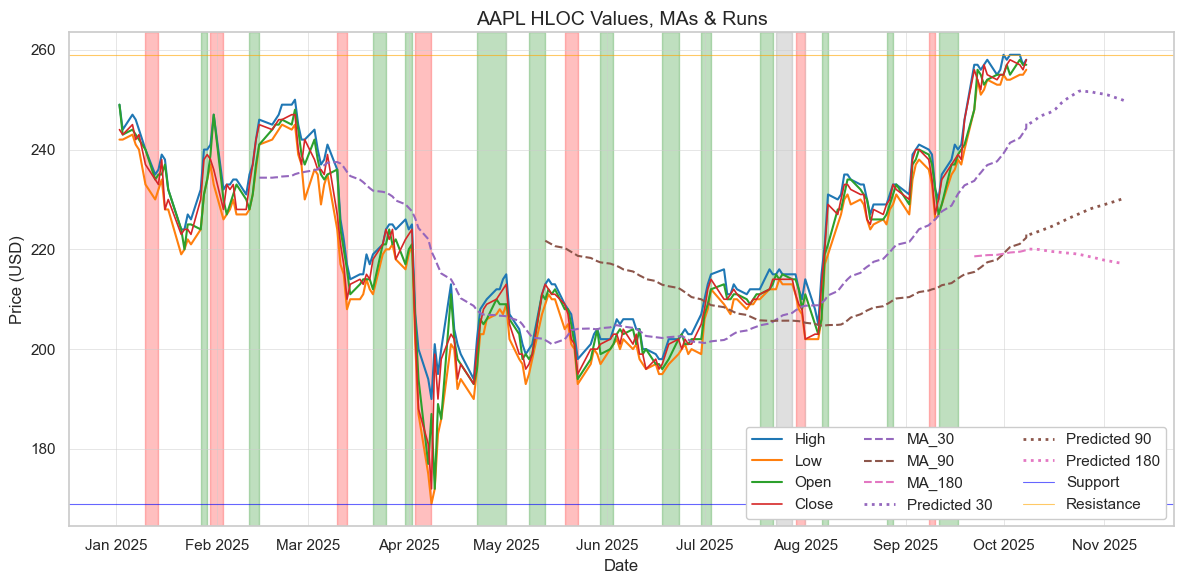

[plot_stock_data] Time elapsed: 0.403355 seconds
[plot_stock_data] Peak memory: 0.00 KB

📈 Plotting AMZN...
[plot_base_prices] Time elapsed: 0.003552 seconds
[plot_base_prices] Peak memory: 399.60 KB
[plot_moving_averages] Time elapsed: 0.002119 seconds
[plot_moving_averages] Peak memory: 66.10 KB
[plot_predictions] Time elapsed: 0.003114 seconds
[plot_predictions] Peak memory: 46.18 KB
[plot_support_resistance] Time elapsed: 0.003539 seconds
[plot_support_resistance] Peak memory: 37.39 KB
[highlight_run_segments] Time elapsed: 0.026119 seconds
[highlight_run_segments] Peak memory: 215.24 KB
[format_axes] Time elapsed: 0.193639 seconds
[format_axes] Peak memory: 687.40 KB


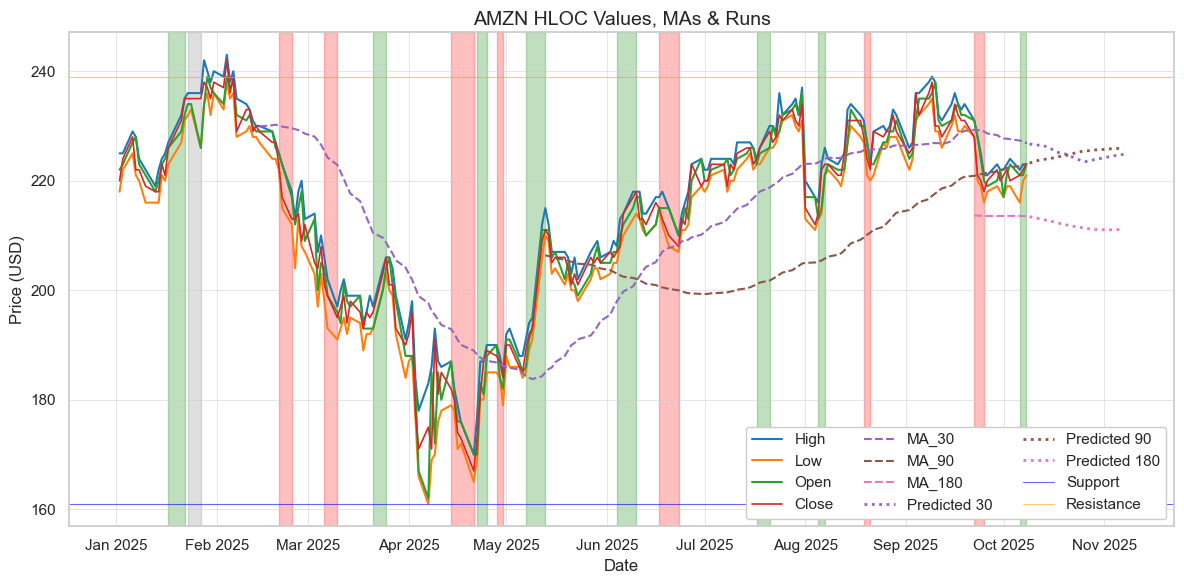

[plot_stock_data] Time elapsed: 0.388052 seconds
[plot_stock_data] Peak memory: 0.00 KB

📈 Plotting GOOGL...
[plot_base_prices] Time elapsed: 0.002955 seconds
[plot_base_prices] Peak memory: 398.86 KB
[plot_moving_averages] Time elapsed: 0.002158 seconds
[plot_moving_averages] Peak memory: 65.56 KB
[plot_predictions] Time elapsed: 0.002853 seconds
[plot_predictions] Peak memory: 46.03 KB
[plot_support_resistance] Time elapsed: 0.003232 seconds
[plot_support_resistance] Peak memory: 37.74 KB
[highlight_run_segments] Time elapsed: 0.032546 seconds
[highlight_run_segments] Peak memory: 245.70 KB
[format_axes] Time elapsed: 0.201263 seconds
[format_axes] Peak memory: 748.81 KB


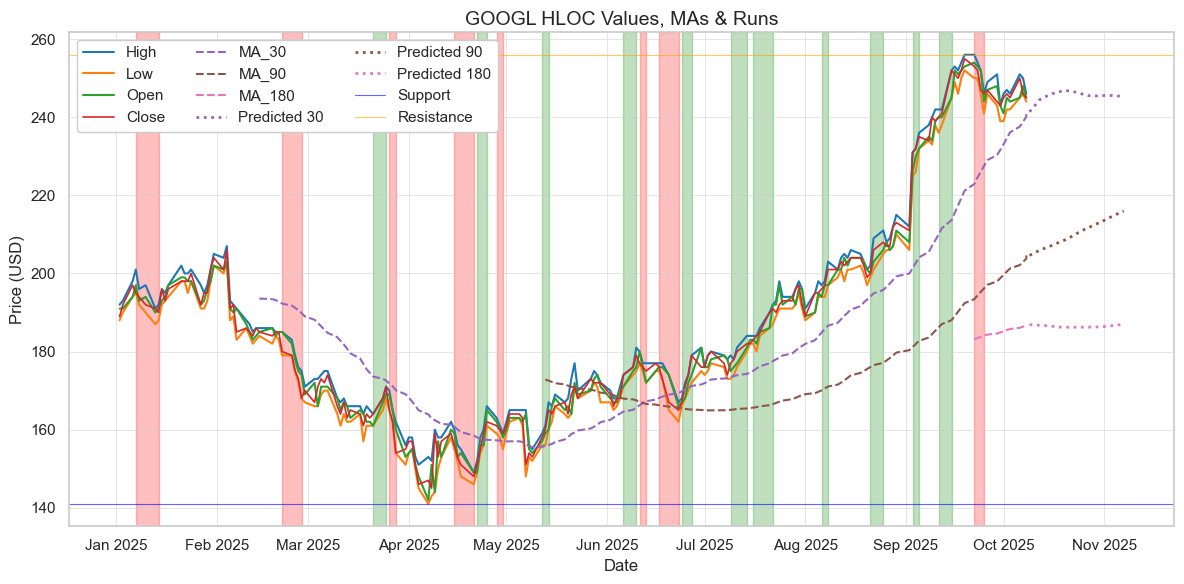

[plot_stock_data] Time elapsed: 0.403101 seconds
[plot_stock_data] Peak memory: 0.00 KB

📈 Plotting META...
[plot_base_prices] Time elapsed: 0.003638 seconds
[plot_base_prices] Peak memory: 414.96 KB
[plot_moving_averages] Time elapsed: 0.002637 seconds
[plot_moving_averages] Peak memory: 67.77 KB
[plot_predictions] Time elapsed: 0.002979 seconds
[plot_predictions] Peak memory: 54.04 KB
[plot_support_resistance] Time elapsed: 0.004325 seconds
[plot_support_resistance] Peak memory: 42.36 KB
[highlight_run_segments] Time elapsed: 0.028703 seconds
[highlight_run_segments] Peak memory: 272.33 KB
[format_axes] Time elapsed: 0.202245 seconds
[format_axes] Peak memory: 752.57 KB


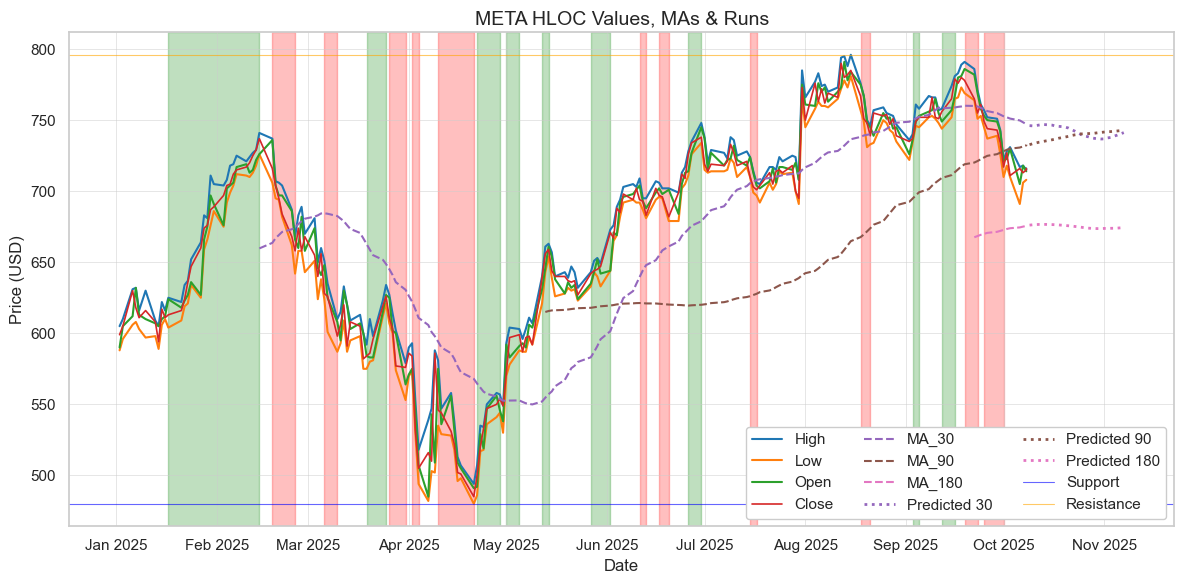

[plot_stock_data] Time elapsed: 0.489669 seconds
[plot_stock_data] Peak memory: 0.00 KB

📈 Plotting MSFT...
[plot_base_prices] Time elapsed: 0.003202 seconds
[plot_base_prices] Peak memory: 399.10 KB
[plot_moving_averages] Time elapsed: 0.002256 seconds
[plot_moving_averages] Peak memory: 66.44 KB
[plot_predictions] Time elapsed: 0.003226 seconds
[plot_predictions] Peak memory: 52.61 KB
[plot_support_resistance] Time elapsed: 0.003670 seconds
[plot_support_resistance] Peak memory: 37.95 KB
[highlight_run_segments] Time elapsed: 0.027926 seconds
[highlight_run_segments] Peak memory: 234.68 KB
[format_axes] Time elapsed: 0.212190 seconds
[format_axes] Peak memory: 699.85 KB


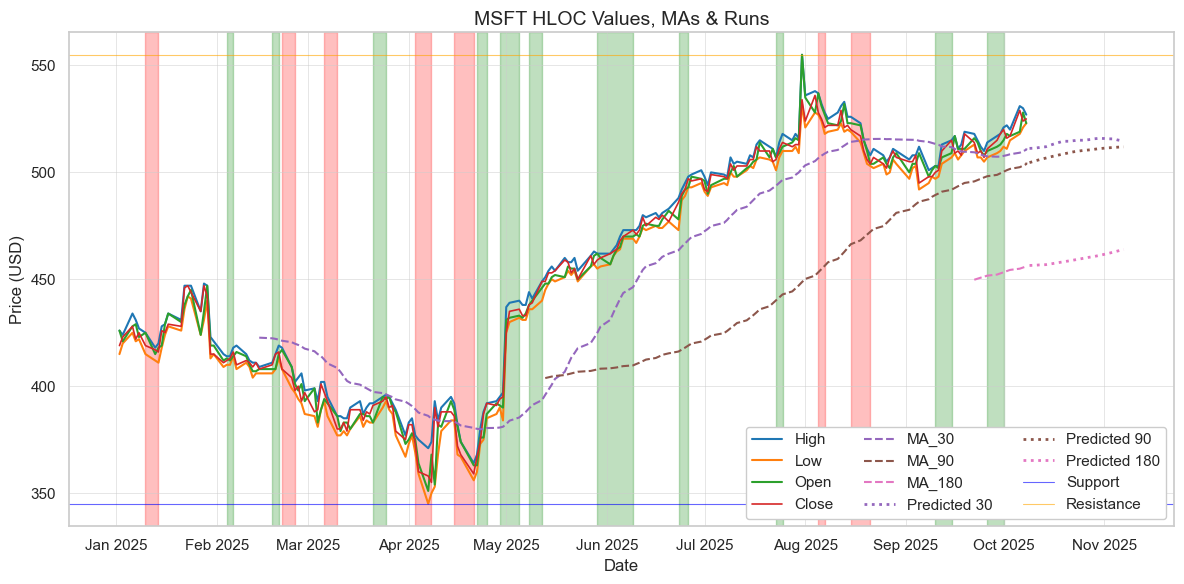

[plot_stock_data] Time elapsed: 0.408539 seconds
[plot_stock_data] Peak memory: 0.00 KB

📈 Plotting NVDA...
[plot_base_prices] Time elapsed: 0.004210 seconds
[plot_base_prices] Peak memory: 398.96 KB
[plot_moving_averages] Time elapsed: 0.002408 seconds
[plot_moving_averages] Peak memory: 64.95 KB
[plot_predictions] Time elapsed: 0.002994 seconds
[plot_predictions] Peak memory: 46.04 KB
[plot_support_resistance] Time elapsed: 0.003265 seconds
[plot_support_resistance] Peak memory: 37.26 KB
[highlight_run_segments] Time elapsed: 0.037916 seconds
[highlight_run_segments] Peak memory: 242.72 KB
[format_axes] Time elapsed: 0.192281 seconds
[format_axes] Peak memory: 701.98 KB


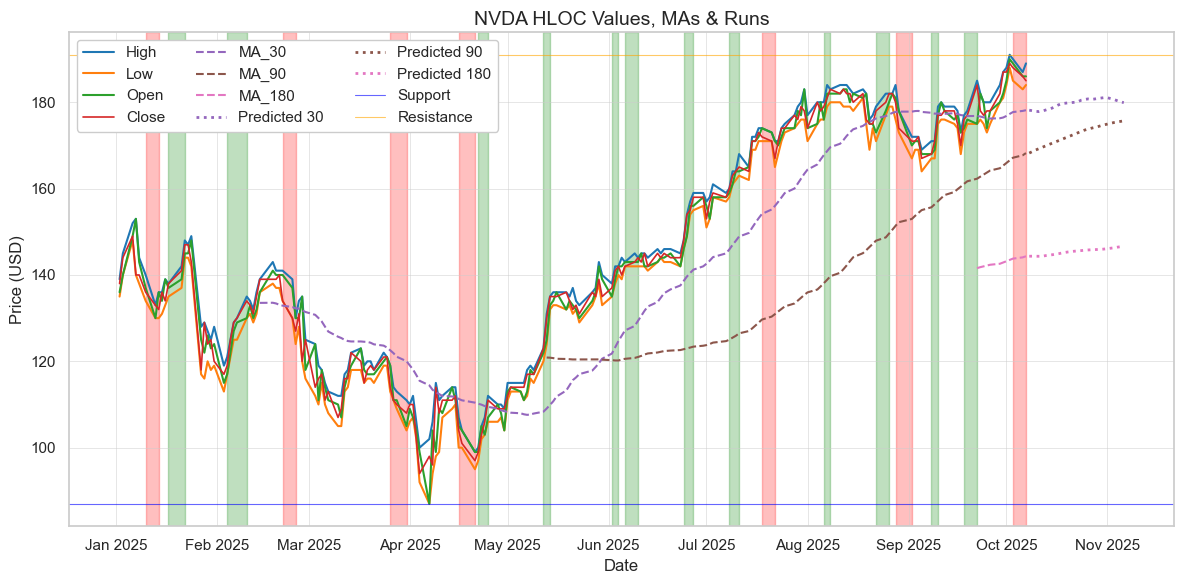

[plot_stock_data] Time elapsed: 0.400770 seconds
[plot_stock_data] Peak memory: 0.00 KB

📈 Plotting TSLA...
[plot_base_prices] Time elapsed: 0.003603 seconds
[plot_base_prices] Peak memory: 399.56 KB
[plot_moving_averages] Time elapsed: 0.002318 seconds
[plot_moving_averages] Peak memory: 66.11 KB
[plot_predictions] Time elapsed: 0.003064 seconds
[plot_predictions] Peak memory: 51.26 KB
[plot_support_resistance] Time elapsed: 0.003433 seconds
[plot_support_resistance] Peak memory: 37.56 KB
[highlight_run_segments] Time elapsed: 0.029982 seconds
[highlight_run_segments] Peak memory: 258.13 KB
[format_axes] Time elapsed: 0.192971 seconds
[format_axes] Peak memory: 694.21 KB


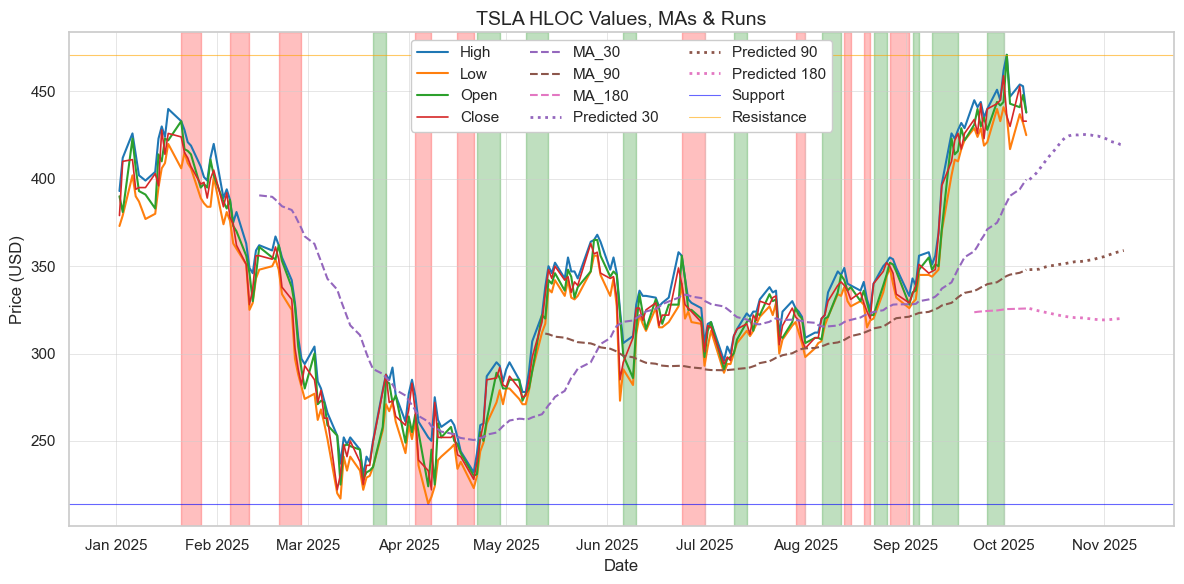

[plot_stock_data] Time elapsed: 0.396115 seconds
[plot_stock_data] Peak memory: 0.00 KB


In [ ]:
# Assuming combined_df has all MAG7 stocks
for name, group in dataset.groupby(COL_NAME):
    print(f"\n📈 Plotting {name}...")
    plot_stock_data(group, save_fig=True)

In [12]:
dataset["Daily_Return"] 

0        NaN
1      -0.41
2       0.82
3      -1.22
4       0.41
        ... 
1343   -5.01
1344   -1.38
1345    5.35
1346   -4.42
1347    0.00
Name: Daily_Return, Length: 1348, dtype: float64